**Heart Disease Predication**

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# for splitting data and scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ml models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# for checking accuracy and other scores
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# for neural network
import tensorflow as tf
from tensorflow import keras

print('libraries imported successfully')

libraries imported successfully


Read and Upload Dataset

In [15]:
df = pd.read_csv("/content/heart.csv")
print(f"Shape: {df.shape}")
df.head(10)

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


In [ ]:
df.info()
print(df.isnull().sum())
print()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


There is no null values in dataset.

In [17]:
#chcking how many patients have heart disease and how many don't
print(df['target'].value_counts(), "\n1= heart disease, 0 = no heart disease")



target
1    165
0    138
Name: count, dtype: int64 
1= heart disease, 0 = no heart disease


Data Visualization (EDA)

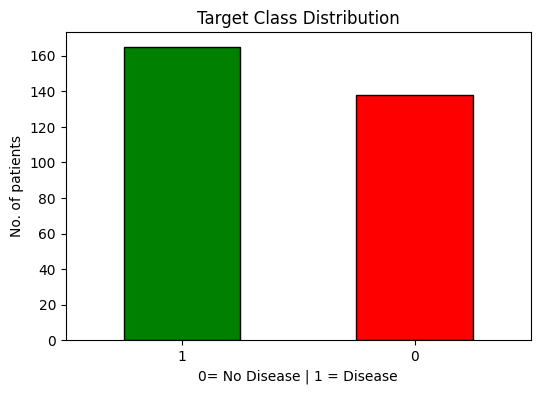

In [19]:
#how many patients have heart disease vs not
plt.figure(figsize=(6,4))
df['target'].value_counts().plot(kind='bar', color=["green", "red"], edgecolor="black", width=0.5)
plt.title('Target Class Distribution')
plt.xlabel('0= No Disease | 1 = Disease')
plt.ylabel('No. of patients')
plt.xticks(rotation=0)
plt.show()

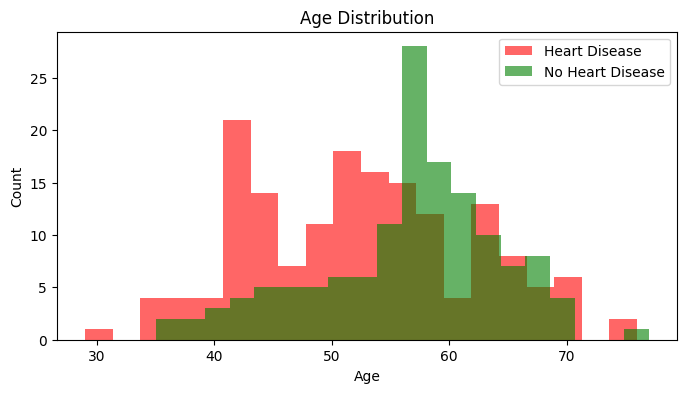

In [21]:
# Age distribution for both groups
plt.figure(figsize=(8, 4))
plt.hist(df[df['target']==1]['age'], bins=20, alpha=0.6, label="Heart Disease", color="red")
plt.hist(df[df['target']==0]['age'], bins=20, alpha=0.6, label="No Heart Disease", color="green")
plt.title("Age Distribution")
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

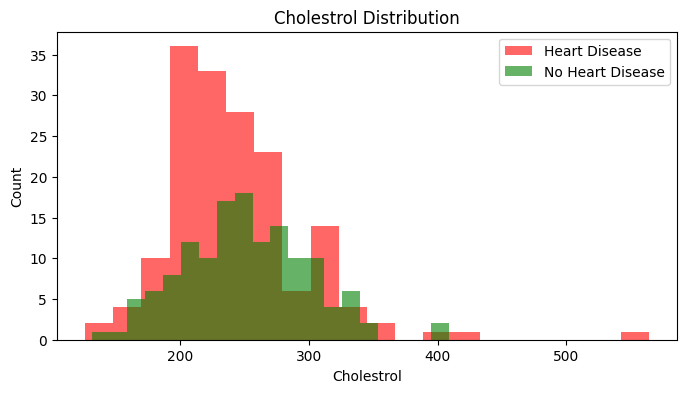

In [22]:
#cholestrol distribution
plt.figure(figsize=(8, 4))
plt.hist(df[df['target']==1]['chol'], bins=20, alpha=0.6, label="Heart Disease", color="red")
plt.hist(df[df['target']==0]['chol'], bins=20, alpha=0.6, label="No Heart Disease", color="green")
plt.title("Cholestrol Distribution")
plt.xlabel('Cholestrol')
plt.ylabel('Count')
plt.legend()
plt.show()

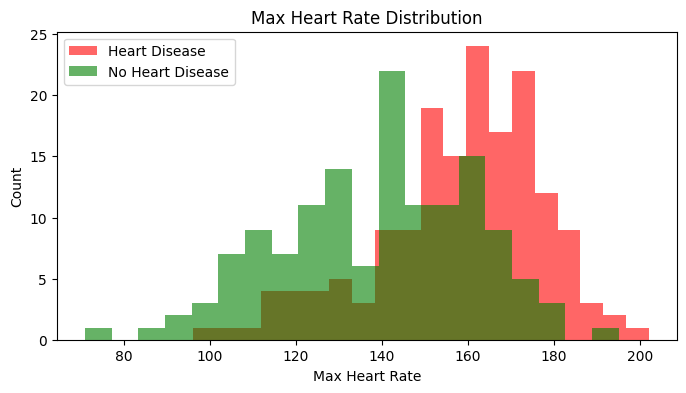

In [23]:
#max heart rate distribution

plt.figure(figsize=(8, 4))
plt.hist(df[df['target']==1]['thalach'], bins=20, alpha=0.6, label="Heart Disease", color="red")
plt.hist(df[df['target']==0]['thalach'], bins=20, alpha=0.6, label="No Heart Disease", color="green")
plt.title("Max Heart Rate Distribution")
plt.xlabel('Max Heart Rate')
plt.ylabel('Count')
plt.legend()
plt.show()

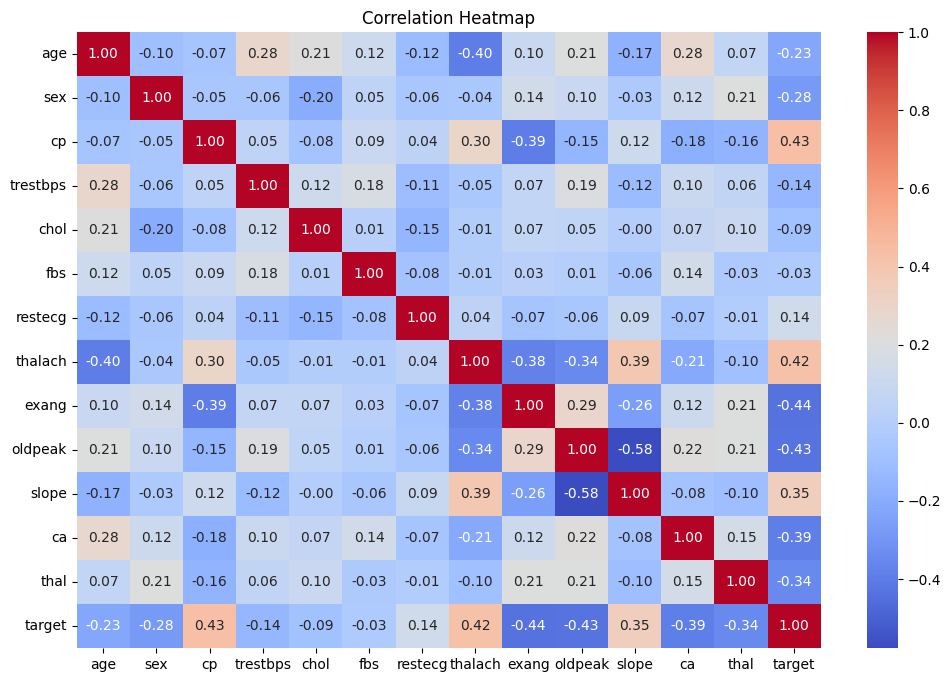

In [24]:
#correlation heatmap to see which features are related to each other
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True,fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

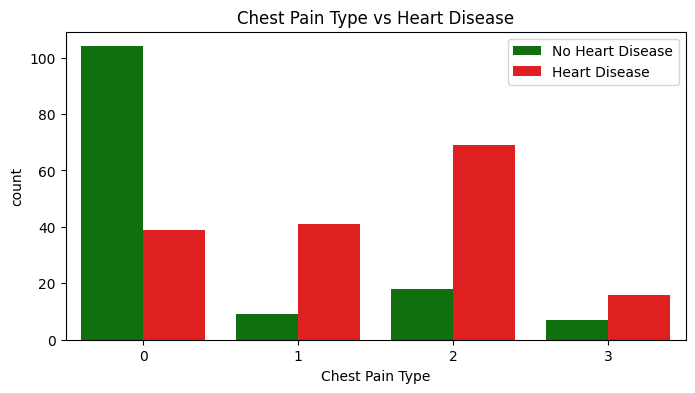

In [25]:
#how chest pain type relates to heart disease

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='cp', hue='target', palette=['green', 'red'])
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel('Chest Pain Type')
plt.legend(['No Heart Disease', 'Heart Disease'])
plt.show()

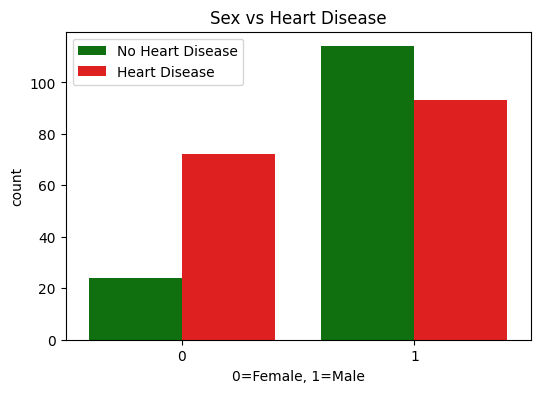

In [26]:
#sex vs heart disease
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sex', hue='target', palette=['green', 'red'])
plt.title("Sex vs Heart Disease")
plt.xlabel('0=Female, 1=Male')
plt.legend(['No Heart Disease', 'Heart Disease'])
plt.show()

Preparing Data for Models

In [29]:
X = df.drop('target', axis=1)
y = df['target']
print(X.shape, y.shape)

(303, 13) (303,)


In [30]:
#80% training, 20% testing

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 242
Testing samples: 61


In [33]:
# scaling the data
# this makes all features have similar range
# needed for logistic regression and neural network

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Model 1: Logistic Regression

In [35]:
#traing the regression model
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

#predications
lr_predictions = lr.predict(X_test_scaled)

#accuracy
lr_accuracy = accuracy_score(y_test, lr_predictions)
print("Logistic Regression Accuracy:", round(lr_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 85.25 %


In [37]:
# detailed report for lr
print(classification_report(y_test, lr_predictions, target_names=['No Heart Disease', 'Heart Disease']))

                  precision    recall  f1-score   support

No Heart Disease       0.83      0.86      0.85        29
   Heart Disease       0.87      0.84      0.86        32

        accuracy                           0.85        61
       macro avg       0.85      0.85      0.85        61
    weighted avg       0.85      0.85      0.85        61



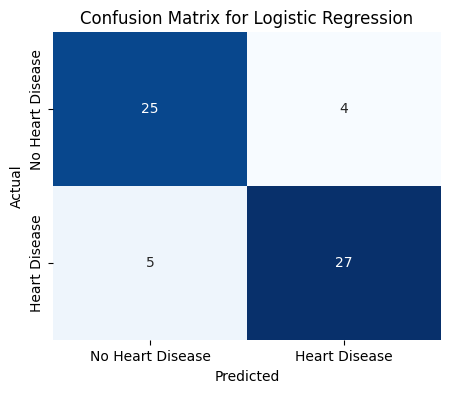

In [38]:
# confusion matrix for lr
cm_lr = confusion_matrix(y_test, lr_predictions)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title('Confusion Matrix for Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Model 2: Decision Tree

In [39]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

dt_predictions = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_predictions)
print("Decision Tree Accuracy:", round(dt_accuracy * 100, 2), "%")

Decision Tree Accuracy: 81.97 %


In [40]:
#detailed report for dt

print(classification_report(y_test, dt_predictions, target_names=['No Heart Disease', 'Heart Disease']))

                  precision    recall  f1-score   support

No Heart Disease       0.82      0.79      0.81        29
   Heart Disease       0.82      0.84      0.83        32

        accuracy                           0.82        61
       macro avg       0.82      0.82      0.82        61
    weighted avg       0.82      0.82      0.82        61



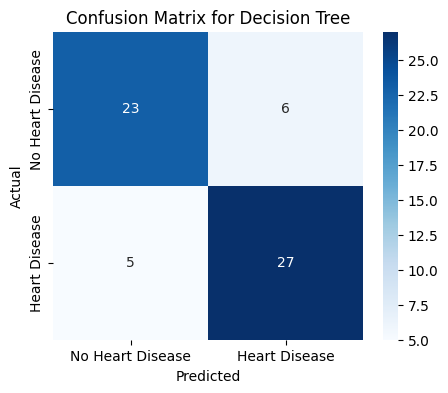

In [41]:
# confusion matrix for dt

cm_dt = confusion_matrix(y_test, dt_predictions)
plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title('Confusion Matrix for Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Model 3: Random Forest

In [42]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)
print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 83.61 %


In [43]:
#detailed report for rf
print(classification_report(y_test, rf_predictions, target_names=['No Heart Disease', 'Heart Disease']))

                  precision    recall  f1-score   support

No Heart Disease       0.83      0.83      0.83        29
   Heart Disease       0.84      0.84      0.84        32

        accuracy                           0.84        61
       macro avg       0.84      0.84      0.84        61
    weighted avg       0.84      0.84      0.84        61



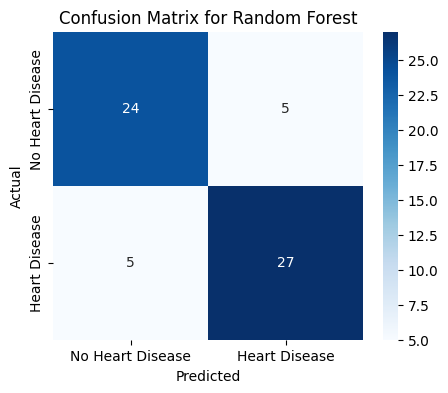

In [44]:
#confusion Matrix for rf
cm_rf = confusion_matrix(y_test, rf_predictions)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title('Confusion Matrix for Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

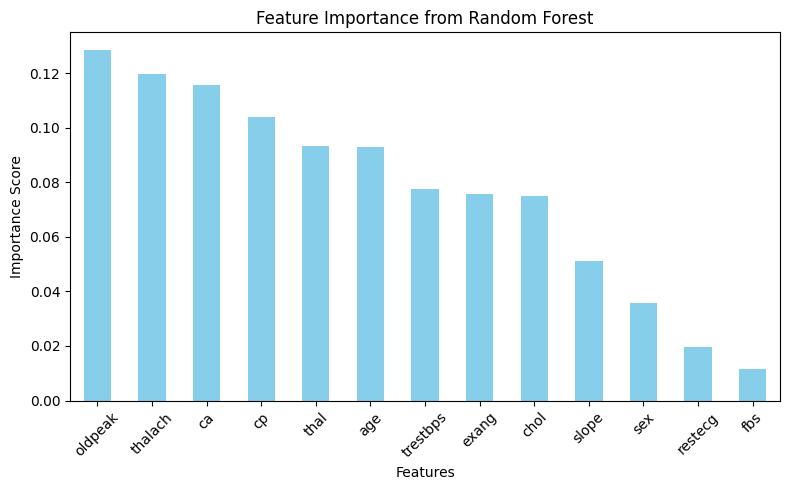

In [45]:
# feature importance from random forest
# this tells which columns were most useful for prediction

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False, inplace=True)

plt.figure(figsize=(8, 5))
feature_importance.plot(kind='bar', color='skyblue')
plt.title('Feature Importance from Random Forest')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Feature Importance Interpretation

From the chart above we can see the actual importance scores from our Random Forest model:

- **oldpeak** is the most important feature. Oldpeak measures ST depression on the ECG during exercise. When the heart is under stress and the ST segment drops significantly, it is a very strong and direct sign that the heart muscle is not getting enough blood. Doctors rely heavily on this value during stress tests.

- **thalach)** is the second most important. This is the maximum heart rate a patient achieved during exercise. People with heart disease usually cannot push their heart rate very high because the heart is already struggling. So a lower max heart rate is a warning sign.

- **ca** comes third. This is the number of major blood vessels blocked or narrowed. More blocked vessels means less blood reaching the heart muscle. So higher ca value directly means more disease.

- **cp** is chest pain type. Chest pain is the most visible symptom of heart disease so it makes sense that it is in the top features. Different types of chest pain carry different levels of risk.

- **thal** is thalassemia type. A reversible defect means blood flow to the heart is reduced during exercise but recovers at rest. This is a classic pattern of coronary artery disease.

- **fbs** is the least important feature in this dataset. Fasting blood sugar being high means the patient may have diabetes, but diabetes alone does not directly cause the heart to malfunction in the short term. That is why it ranked last here.

In [46]:
# Hyperparameter Tuning (Random Forest)

param_grid = {'n_estimators': [50, 100 , 200], 'max_depth':[3, 5,7]}

# GridSearchCV tries all combinations and picks the best one
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3)
grid.fit(X_train, y_train)

best_params = grid.best_params_
print("Best Hyperparameters:", best_params)

print("Best cross validation score:", round(grid.best_score_ * 100, 2), "%")

Best Hyperparameters: {'max_depth': 3, 'n_estimators': 50}
Best cross validation score: 81.83 %


In [49]:
# testing the best model on test data
best_rf = grid.best_estimator_
best_rf_predictions = best_rf.predict(X_test)

best_rf_accuracy = accuracy_score(y_test, best_rf_predictions)
print('Tuned Random Forest Accuracy:', round(best_rf_accuracy * 100, 2), '%\n')
print('Classification Report after tuning:')
print(classification_report(y_test, best_rf_predictions, target_names=['No Heart Disease', 'Heart Disease']))

Tuned Random Forest Accuracy: 88.52 %

Classification Report after tuning:
                  precision    recall  f1-score   support

No Heart Disease       0.89      0.86      0.88        29
   Heart Disease       0.88      0.91      0.89        32

        accuracy                           0.89        61
       macro avg       0.89      0.88      0.88        61
    weighted avg       0.89      0.89      0.89        61



Model 4: Neural Network

In [50]:
tf.random.set_seed(42)

# neural network
nn = keras.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=(13,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# training the neural network
history = nn.fit(X_train_scaled, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.4101 - loss: 0.8043 - val_accuracy: 0.5200 - val_loss: 0.7154
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5991 - loss: 0.6595 - val_accuracy: 0.7200 - val_loss: 0.5869
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7327 - loss: 0.5748 - val_accuracy: 0.8000 - val_loss: 0.5048
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7604 - loss: 0.5215 - val_accuracy: 0.8400 - val_loss: 0.4501
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7604 - loss: 0.4834 - val_accuracy: 0.8400 - val_loss: 0.4126
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7880 - loss: 0.4546 - val_accuracy: 0.8800 - val_loss: 0.3858
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7972 - loss: 0.4318 - val_accuracy: 0.8800 - val_loss: 0.3666
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8065 - loss: 0.4128 - val_accuracy: 0.8800 - val_

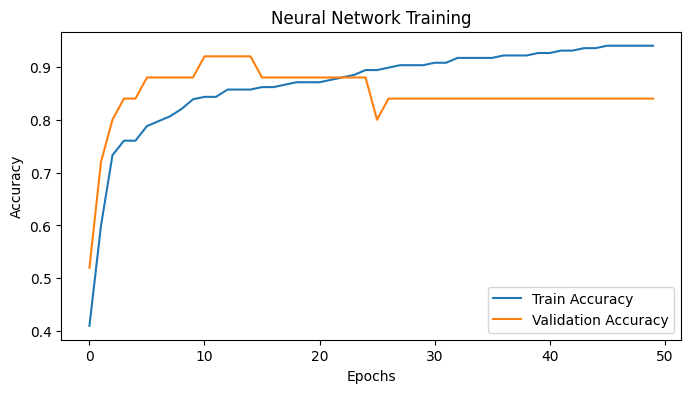

In [54]:
# plotting training accuracy and validation accuracy
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Neural Network Training')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

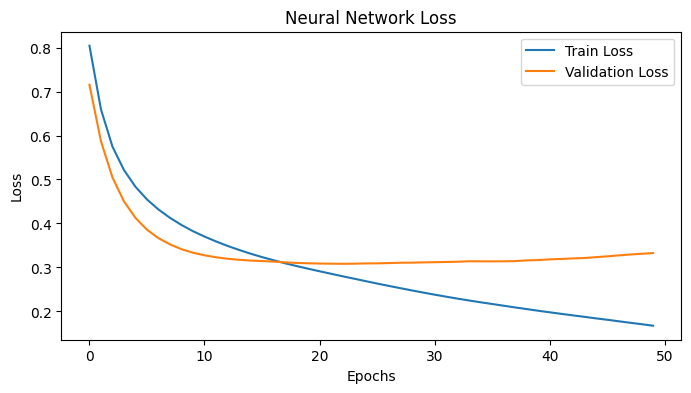

In [55]:
# plotting loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Neural Network Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [56]:
nn_prob = nn.predict(X_test_scaled)

# converting probabilities to 0 or 1
nn_predictions = (nn_prob > 0.5).astype(int).flatten()

# checking accuracy
nn_accuracy = accuracy_score(y_test, nn_predictions)
print("Neural Network Accuracy:", round(nn_accuracy * 100, 2), "%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Neural Network Accuracy: 78.69 %


In [57]:
print('Classification Report for Neural Network:')
print(classification_report(y_test, nn_predictions, target_names=['No Disease', 'Heart Disease']))

Classification Report for Neural Network:
               precision    recall  f1-score   support

   No Disease       0.75      0.83      0.79        29
Heart Disease       0.83      0.75      0.79        32

     accuracy                           0.79        61
    macro avg       0.79      0.79      0.79        61
 weighted avg       0.79      0.79      0.79        61



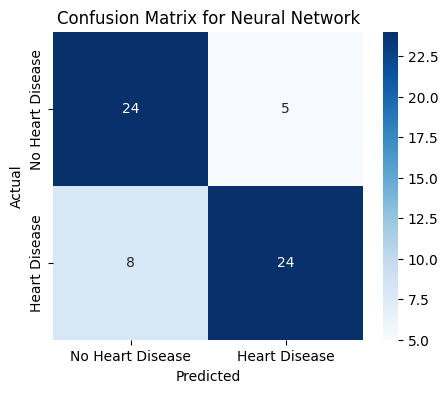

In [58]:
cm_nn = confusion_matrix(y_test, nn_predictions)
plt.figure(figsize=(5,4))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title('Confusion Matrix for Neural Network')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

ROC Curves for All models

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


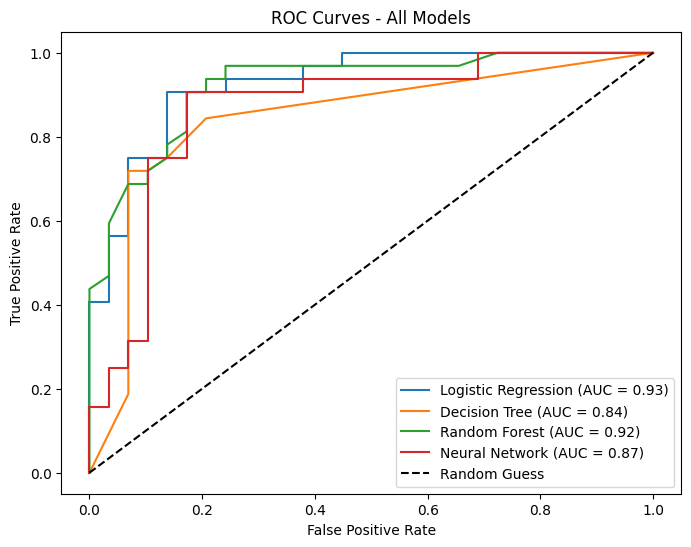

In [59]:
# getting probabilities for roc curve from each model
lr_prob  = lr.predict_proba(X_test_scaled)[:, 1]
dt_prob  = dt.predict_proba(X_test)[:, 1]
rf_prob  = rf.predict_proba(X_test)[:, 1]
nn_prob2 = nn.predict(X_test_scaled).flatten()

# calculating roc curve for each
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
nn_fpr, nn_tpr, _ = roc_curve(y_test, nn_prob2)

# calculating auc scores
lr_auc = roc_auc_score(y_test, lr_prob)
dt_auc = roc_auc_score(y_test, dt_prob)
rf_auc = roc_auc_score(y_test, rf_prob)
nn_auc = roc_auc_score(y_test, nn_prob2)

# plotting all roc curves together
plt.figure(figsize=(8,6))
plt.plot(lr_fpr, lr_tpr, label='Logistic Regression (AUC = ' + str(round(lr_auc, 2)) + ')')
plt.plot(dt_fpr, dt_tpr, label='Decision Tree (AUC = ' + str(round(dt_auc, 2)) + ')')
plt.plot(rf_fpr, rf_tpr, label='Random Forest (AUC = ' + str(round(rf_auc, 2)) + ')')
plt.plot(nn_fpr, nn_tpr, label='Neural Network (AUC = ' + str(round(nn_auc, 2)) + ')')
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.title('ROC Curves - All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

Comparing All models

In [60]:
# putting all results in one table to compare

results = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Neural Network'],
    'Accuracy': [
        round(accuracy_score(y_test, lr_predictions) * 100, 2),
        round(accuracy_score(y_test, dt_predictions) * 100, 2),
        round(accuracy_score(y_test, rf_predictions) * 100, 2),
        round(accuracy_score(y_test, nn_predictions) * 100, 2)
    ],
    'Precision': [
        round(precision_score(y_test, lr_predictions) * 100, 2),
        round(precision_score(y_test, dt_predictions) * 100, 2),
        round(precision_score(y_test, rf_predictions) * 100, 2),
        round(precision_score(y_test, nn_predictions) * 100, 2)
    ],
    'Recall': [
        round(recall_score(y_test, lr_predictions) * 100, 2),
        round(recall_score(y_test, dt_predictions) * 100, 2),
        round(recall_score(y_test, rf_predictions) * 100, 2),
        round(recall_score(y_test, nn_predictions) * 100, 2)
    ],
    'F1 Score': [
        round(f1_score(y_test, lr_predictions) * 100, 2),
        round(f1_score(y_test, dt_predictions) * 100, 2),
        round(f1_score(y_test, rf_predictions) * 100, 2),
        round(f1_score(y_test, nn_predictions) * 100, 2)
    ],
    'ROC AUC': [
        round(lr_auc * 100, 2),
        round(dt_auc * 100, 2),
        round(rf_auc * 100, 2),
        round(nn_auc * 100, 2)
    ]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
Logistic Regression     85.25      87.10   84.38     85.71    92.67
      Decision Tree     81.97      81.82   84.38     83.08    84.27
      Random Forest     83.61      84.38   84.38     84.38    92.24
     Neural Network     78.69      82.76   75.00     78.69    86.53


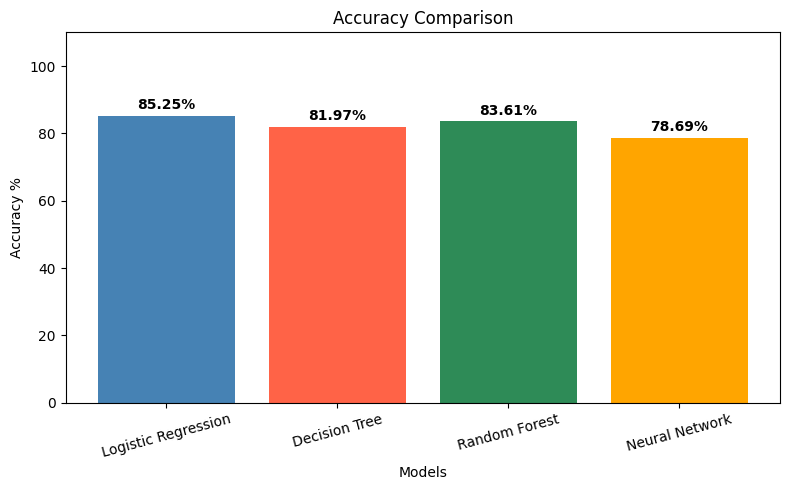

In [61]:
plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['Accuracy'], color=['steelblue','tomato','seagreen','orange'])
plt.title('Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy %')
plt.ylim(0, 110)

for i in range(len(results_df)):
  plt.text(i, results_df['Accuracy'][i] + 1, str(results_df['Accuracy'][i]) + '%', ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [62]:
 # finding which model performed best

 best_model = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
 print(f"The best model is: {best_model}")

 best_accuracy = results_df['Accuracy'].max()
 print(f"Accuracy: {best_accuracy:.2f}%")

The best model is: Logistic Regression
Accuracy: 85.25%


In [63]:
# test on sample patient data

new_patient = [[52, 1, 0, 125, 212, 0, 1, 168, 0, 1.0, 2, 2, 3]]

# scaling the new patient data using same scaler
new_patient_scaled = scaler.transform(new_patient)

# predicting using logistic regression
lr_result = lr.predict(new_patient_scaled)[0]
lr_conf = lr.predict_proba(new_patient_scaled)[0][1]

# predicting using random forest
rf_result = rf.predict(new_patient)[0]
rf_conf = rf.predict_proba(new_patient)[0][1]

# predicting using neural network
nn_result_prob = nn.predict(new_patient_scaled)[0][0]
nn_result = 1 if nn_result_prob > 0.5 else 0

print('--- Prediction for New Patient ---')
print()

if lr_result == 1:
    print('Logistic Regression: Heart Disease Detected (', round(lr_conf*100, 1), '% confidence)')
else:
    print('Logistic Regression: No Heart Disease (', round((1-lr_conf)*100, 1), '% confidence)')

if rf_result == 1:
    print('Random Forest      : Heart Disease Detected (', round(rf_conf*100, 1), '% confidence)')
else:
    print('Random Forest      : No Heart Disease (', round((1-rf_conf)*100, 1), '% confidence)')

if nn_result == 1:
    print('Neural Network     : Heart Disease Detected (', round(nn_result_prob*100, 1), '% confidence)')
else:
    print('Neural Network     : No Heart Disease (', round((1-nn_result_prob)*100, 1), '% confidence)')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
--- Prediction for New Patient ---

Logistic Regression: No Heart Disease ( 100.0 % confidence)
Random Forest      : Heart Disease Detected ( 54.0 % confidence)
Neural Network     : Heart Disease Detected ( 100.0 % confidence)


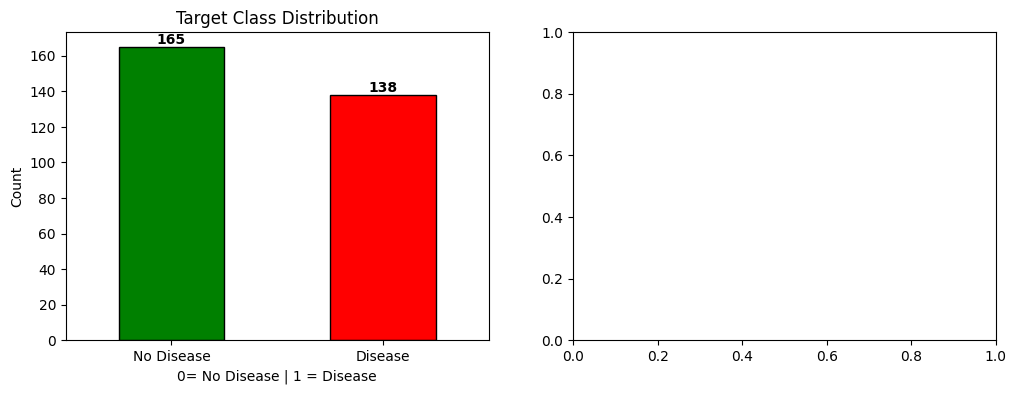

In [ ]:
# target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#count plot
df['target'].value_counts().plot(kind='bar', ax=axes[0], color=["green", "red"], edgecolor="black", width=0.5)
axes[0].set_title('Target Class Distribution')
axes[0].set_xlabel('0= No Disease | 1 = Disease')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Disease', 'Disease'], rotation=0)
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())), (p.get_x() + p.get_width()/2, p.get_height()), ha="center", va="bottom", fontweight="bold")



## Conclusion

In this project I built 4 machine learning models to predict heart disease using the Heart Disease dataset which has 303 patients and 13 features.

**Actual results after running all models:**

| Model | Accuracy | Precision | Recall | F1 Score | ROC AUC |
|---|---|---|---|---|---|
| Logistic Regression | 85.25% | 87.10% | 84.38% | 85.71% | 92.67% |
| Decision Tree | 81.97% | 81.82% | 84.38% | 83.08% | 84.27% |
| Random Forest | 83.61% | 84.38% | 84.38% | 84.38% | 92.24% |
| Neural Network | 78.69% | 82.76% | 75.00% | 78.69% | 86.53% |

**Best model: Logistic Regression** achieved the highest accuracy of 85.25%, highest F1 score of 85.71% and highest ROC-AUC of 92.67% which means it is the best overall at separating heart disease patients from healthy ones.

Logistic Regression is a simple model but it works very well when the dataset is small and clean because it does not overfit. Random Forest and Neural Network need more data to show their full power.

**Hyperparameter tuning** on Random Forest using GridSearchCV found that the best settings were max_depth=3 and n_estimators=50 with a cross validation score of 81.83%.

**Key findings from feature importance:**
- oldpeak, thalach and ca were the top 3 most important features
- fbs was the least important feature with a score of only 0.011

**Overall conclusion:** For this specific dataset, Logistic Regression is the best and most reliable model. It is also the simplest which makes it easier to interpret and explain to doctors and medical staff.